In [106]:
from langgraph.graph import StateGraph, START, END
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict, Annotated, List
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

import requests
import random

In [107]:
load_dotenv()

True

In [108]:
model = ChatGroq(
    model='openai/gpt-oss-120b',
    temperature=0.7
)

In [109]:
# Tools

search_tool = DuckDuckGoSearchRun()

@tool
def calculator(first_num: float, second_num: float, operation: str) -> float:
    """Perform arithmetic operation such as add, sub, div, mul by using first_num and second_num"""
    try:
        if operation=='add':
            result = first_num + second_num
        elif operation=='sub':
            result = first_num - second_num
        elif operation=='mul':
            result = first_num * second_num
        elif operation=='div':
            if second_num==0:
                return {'error': 'divison by zero not allowed'}
            result = first_num / second_num
        else:
            return {'error': f'Unsupported Operation: {operation}'}    
    except Exception as e:
        return {'error': str(e)}
    
@tool
def get_stock_price(symbol: str) -> dict:
    """
    Fetch latest stock price for a given symbol (e.g. 'AAPL', 'TSLA') 
    using Alpha Vantage with API key in the URL.
    """
    url = f"https://www.alphavantage.co/query?function=GLOBAL_QUOTE&symbol={symbol}&apikey=PFHFKL1B75HSIPGP"
    r = requests.get(url)
    return r.json()


tools = [search_tool, calculator, get_stock_price]

llm_with_tool = model.bind_tools(tools)

In [110]:
class ChatState(TypedDict):
    messages: Annotated[List[str], add_messages]

In [111]:
def chat_node(state: ChatState): 
    message = state['messages']
    response = llm_with_tool.invoke(message)

    return {'messages': [response]}

In [112]:
tool_node = ToolNode(tools)

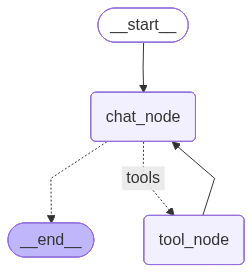

In [113]:
graph = StateGraph(ChatState)

graph.add_node('chat_node', chat_node)
graph.add_node('tool_node', tool_node)

graph.add_edge(START, 'chat_node')
graph.add_conditional_edges('chat_node', tools_condition, {'tools': 'tool_node', '__end__': END})
graph.add_edge('tool_node', 'chat_node')

workflow = graph.compile()
workflow

In [114]:
workflow.invoke({"messages": [HumanMessage(content="HI")]})

{'messages': [HumanMessage(content='HI', additional_kwargs={}, response_metadata={}, id='eb4ddfbc-3c34-419b-9f37-bbc7310adb70'),
  AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'The user says "HI". Likely just a greeting. Should respond politely.'}, response_metadata={'token_usage': {'completion_tokens': 35, 'prompt_tokens': 242, 'total_tokens': 277, 'completion_time': 0.074099185, 'completion_tokens_details': {'reasoning_tokens': 17}, 'prompt_time': 0.010633036, 'prompt_tokens_details': None, 'queue_time': 0.045044373, 'total_time': 0.084732221}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_e10890e4b9', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019d3eac-265b-7783-8a5e-d34737219414-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 242, 'output_tokens': 35, 'total_tokens': 277, 'output_token_details': {'reasoning': 17}})]}

In [115]:
workflow.invoke({"messages": [HumanMessage(content="Today IPL news")]})

{'messages': [HumanMessage(content='Today IPL news', additional_kwargs={}, response_metadata={}, id='54ed6690-28cc-44cd-afb8-c9d590b80248'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'User: "Today IPL news". They want latest IPL news. Need to browse. Use duckduckgo_search with query "IPL news today".', 'tool_calls': [{'id': 'fc_af9508f0-cd2d-43a7-9401-b2729da0dcc9', 'function': {'arguments': '{"query":"IPL news today"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 62, 'prompt_tokens': 244, 'total_tokens': 306, 'completion_time': 0.133519349, 'completion_tokens_details': {'reasoning_tokens': 30}, 'prompt_time': 0.011215736, 'prompt_tokens_details': None, 'queue_time': 1.449814688, 'total_time': 0.144735085}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_a09bde29de', 'service_tier': 'on_demand', 'finish_reason': 'tool_calls', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019